In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [61]:
df = pd.read_csv("../steam_reviews_final.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Review Text    1991 non-null   object
 1   Review Length  2000 non-null   int64 
 2   Thumb Text     2000 non-null   object
 3   Play Hours     2000 non-null   object
 4   Date Posted    2000 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [62]:
drop_df = df.dropna()
renamed_df = drop_df.rename(columns={
    "Review Text":"review_text",
    "Review Length":"review_length",
    "Thumb Text":"feedback",
    "Play Hours":"play_hours",
    "Date Posted":"date_posted"

})
renamed_df.info()
renamed_df.head()



<class 'pandas.core.frame.DataFrame'>
Index: 1991 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_text    1991 non-null   object
 1   review_length  1991 non-null   int64 
 2   feedback       1991 non-null   object
 3   play_hours     1991 non-null   object
 4   date_posted    1991 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.3+ KB


,review_text,review_length,feedback,play_hours,date_posted
0,10 out of 10 game but MJ is the main reason wh...,67,Recommended,44.8 hrs on record,Posted: 6 July
1,best game ever,12,Recommended,16.1 hrs on record,Posted: 6 July
2,"this game is very good, is an anventure game i...",43,Recommended,5.0 hrs on record,Posted: 6 July
3,not well optimized for now,22,Not Recommended,2.5 hrs on record,Posted: 6 July
4,cause,5,Recommended,7.2 hrs on record,Posted: 6 July


In [63]:
renamed_df["play_hours"] = renamed_df["play_hours"].astype(str)

renamed_df["play_hours"] = renamed_df["play_hours"].str.replace(' hrs on record','').astype(float)

renamed_df

,review_text,review_length,feedback,play_hours,date_posted
0,10 out of 10 game but MJ is the main reason wh...,67,Recommended,44.8,Posted: 6 July
1,best game ever,12,Recommended,16.1,Posted: 6 July
2,"this game is very good, is an anventure game i...",43,Recommended,5.0,Posted: 6 July
3,not well optimized for now,22,Not Recommended,2.5,Posted: 6 July
4,cause,5,Recommended,7.2,Posted: 6 July
...,...,...,...,...,...
1995,"The story in this game is disappointing, Krave...",847,Not Recommended,27.7,Posted: April 9
1996,My favourite spider man game by far ^^\n\nI lo...,561,Recommended,41.0,Posted: April 9
1997,good game. just wished it wasnt so heavy on th...,57,Recommended,34.1,Posted: April 9
1998,Not as good as the first one but a great game ...,140,Recommended,26.0,Posted: April 9


In [64]:

import re

month_mapping = {
    "January": "01", "February": "02", "March": "03", "April": "04",
    "May": "05", "June": "06", "July": "07", "August": "08",
    "September": "09", "October": "10", "November": "11", "December": "12"
}

def parse_mixed_date(s):
    s = str(s).strip()
    # Try 'Month Day' (e.g., 'July 6')
    m1 = re.match(r'([A-Za-z]+)\s+(\d{1,2})', s)
    if m1:
        month = month_mapping.get(m1.group(1), None)
        day = m1.group(2).zfill(2)
        if month:
            return f"{day}/{month}/2025"
    # Try 'Day Month' (e.g., '9 April')
    m2 = re.match(r'(\d{1,2})\s+([A-Za-z]+)', s)
    if m2:
        day = m2.group(1).zfill(2)
        month = month_mapping.get(m2.group(2), None)
        if month:
            return f"{day}/{month}/2025"
    return None

renamed_df["date_posted"] = renamed_df["date_posted"].str.replace('Posted: ', '')

renamed_df["date_posted"] = renamed_df["date_posted"].apply(parse_mixed_date)

# Convert to datetime and format
#renamed_df["date_posted"] = pd.to_datetime(renamed_df["date_posted"], format='%d/%m/%Y', errors='coerce').dt.strftime('%d-%m-%Y')
renamed_df["date_posted"] = pd.to_datetime(renamed_df["date_posted"], format='%d/%m/%Y', errors='coerce')


final_df = renamed_df
final_df["feedback"] = final_df["feedback"].replace({"Recommended": 1, "Not Recommended": 0})
final_df.to_csv("../Cleaned_Reviews.csv")
final_df


/var/folders/nz/59m3phqs5rg_30kcvrkxfsrw0000gn/T/ipykernel_34585/2690112534.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df["feedback"] = final_df["feedback"].replace({"Recommended": 1, "Not Recommended": 0})


,review_text,review_length,feedback,play_hours,date_posted
0,10 out of 10 game but MJ is the main reason wh...,67,1,44.8,2025-07-06
1,best game ever,12,1,16.1,2025-07-06
2,"this game is very good, is an anventure game i...",43,1,5.0,2025-07-06
3,not well optimized for now,22,0,2.5,2025-07-06
4,cause,5,1,7.2,2025-07-06
...,...,...,...,...,...
1995,"The story in this game is disappointing, Krave...",847,0,27.7,2025-04-09
1996,My favourite spider man game by far ^^\n\nI lo...,561,1,41.0,2025-04-09
1997,good game. just wished it wasnt so heavy on th...,57,1,34.1,2025-04-09
1998,Not as good as the first one but a great game ...,140,1,26.0,2025-04-09


EDA

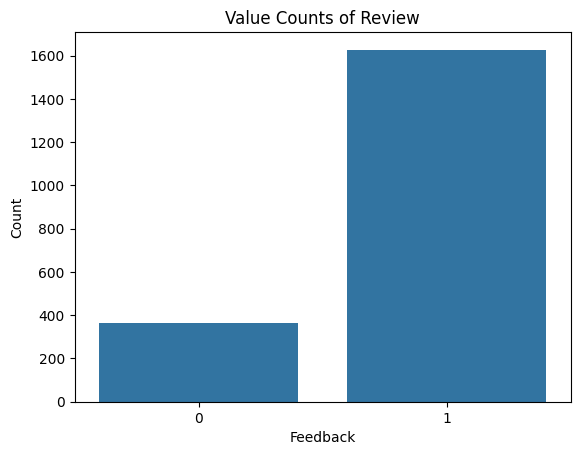

Percentage distribution : 
feedback
1    81.72
0    18.28
Name: count, dtype: float64


In [65]:
sns.barplot(x=renamed_df['feedback'].value_counts().index, 
            y=renamed_df['feedback'].value_counts().values)
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.title('Value Counts of Review')
plt.show()

print(f"Percentage distribution : \n{round(final_df["feedback"].value_counts()/final_df.shape[0]*100,2)}")

Skewness of review_length: 6.297488219471708
Skewness of play_hours: 7.7063295097394775
Skewness of feedback: -1.6424277243359182


([<matplotlib.axis.XTick at 0x12d35f890>,
 [Text(0, 0, 'Not Recommended'), Text(1, 0, 'Recommended')])

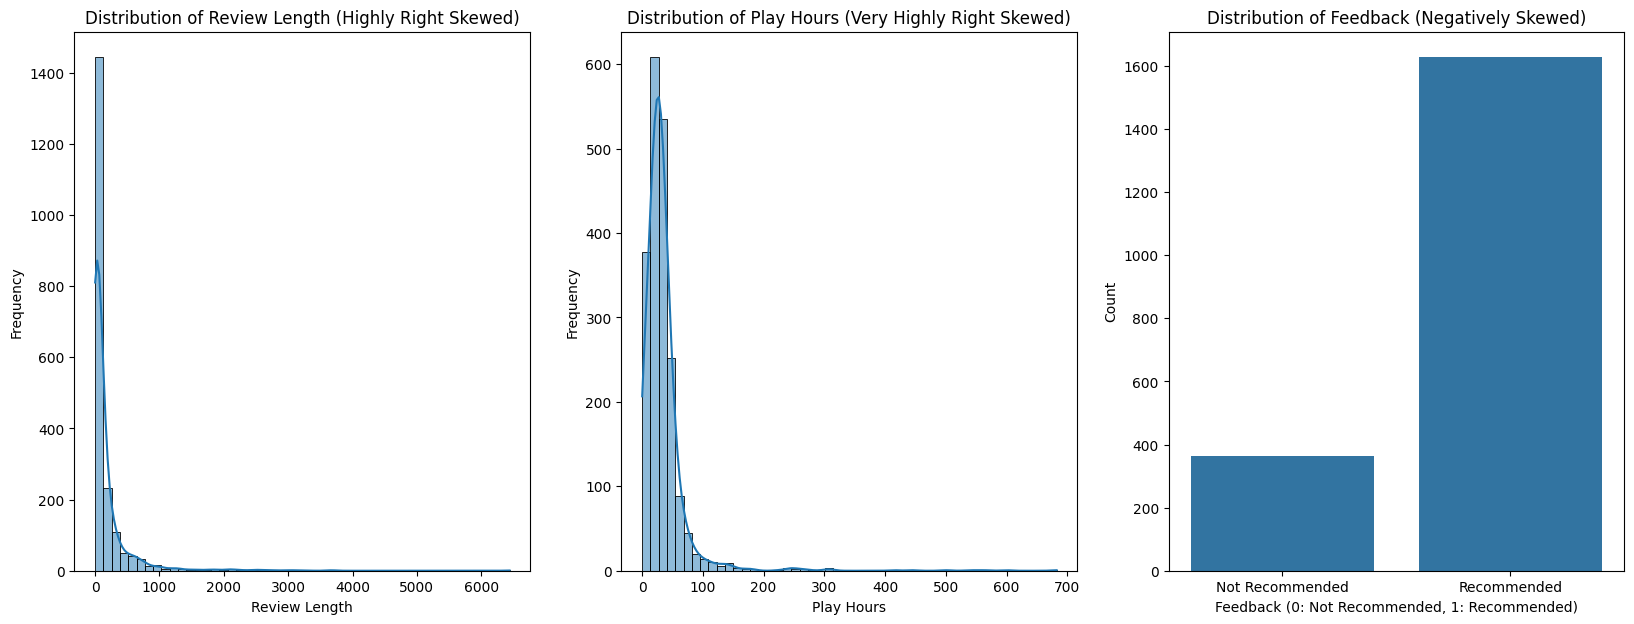

In [66]:
print("Skewness of review_length:", final_df["review_length"].skew())
print("Skewness of play_hours:", final_df["play_hours"].skew())
print("Skewness of feedback:", final_df["feedback"].skew())

plt.figure(figsize=(20, 7))

plt.subplot(1, 3, 1) 
sns.histplot(final_df['review_length'], kde=True, bins=50) 
plt.title('Distribution of Review Length (Highly Right Skewed)')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2) 
sns.histplot(final_df['play_hours'], kde=True, bins=50)
plt.title('Distribution of Play Hours (Very Highly Right Skewed)')
plt.xlabel('Play Hours')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3) 
sns.countplot(x=final_df['feedback'])
plt.title('Distribution of Feedback (Negatively Skewed)')
plt.xlabel('Feedback (0: Not Recommended, 1: Recommended)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Recommended', 'Recommended']) 



1. Skewness of review_length (6.297):
    most people write brief reviews, but a smaller number of players provide very detailed feedback.
2. Skewness of play_hours (7.706):
    Most players have a relatively low number of play hours, and a smaller number of highly dedicated players.Bulk users are casual players
3. Skewness of feedback (−1.642):
    majority of feedback values are concentrated towards the higher end (the 'recommends' side).Positive reviews for this game

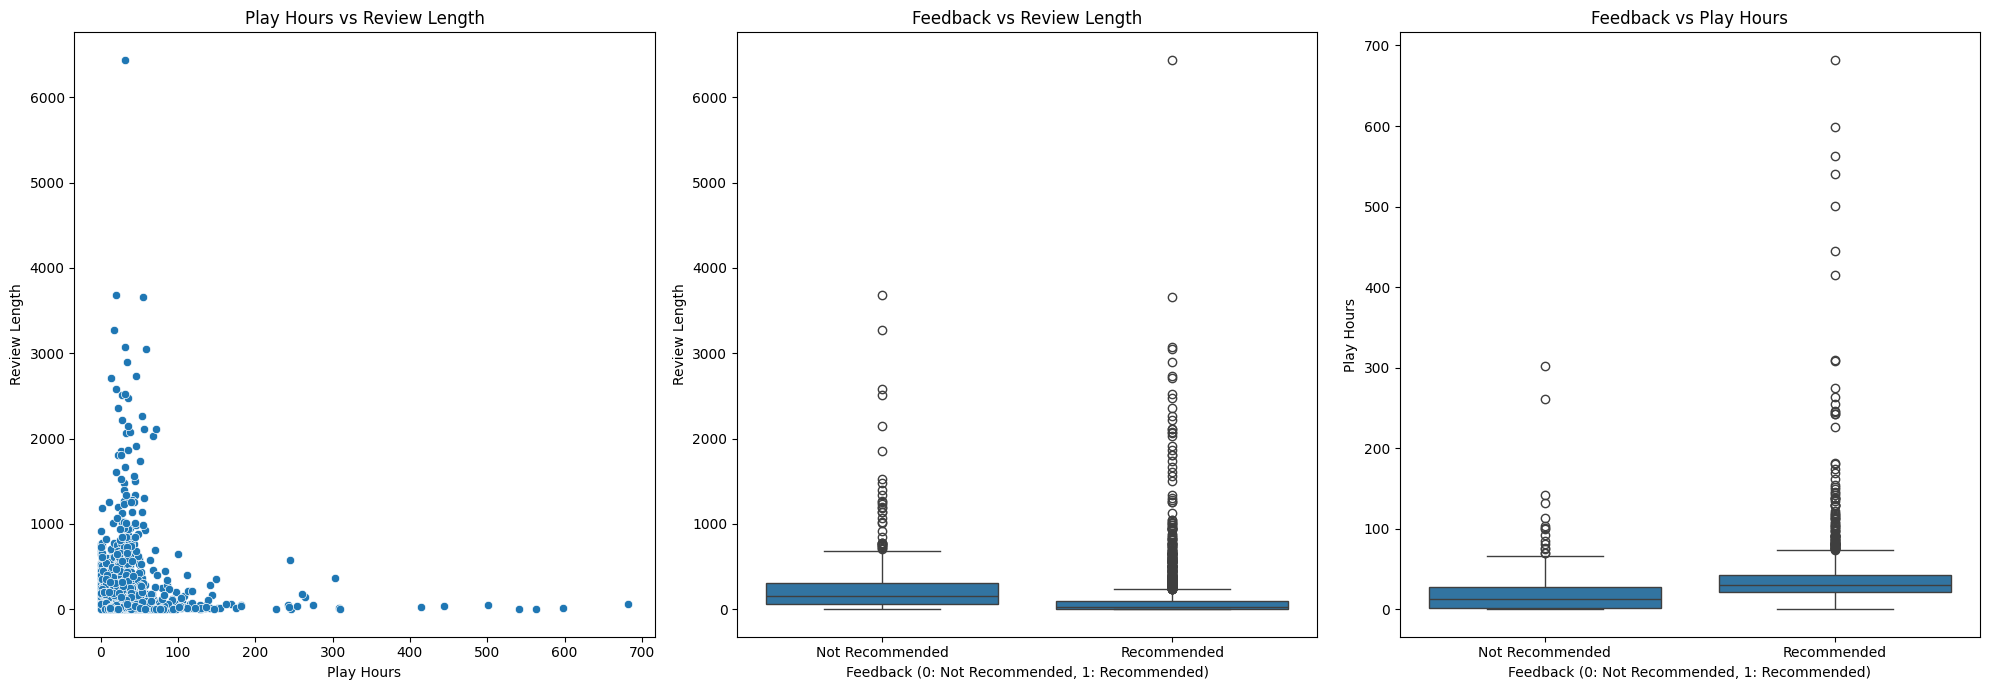

In [67]:
plt.figure(figsize=(20, 7))

plt.subplot(1, 3, 1) 
sns.scatterplot(x=final_df["play_hours"], y=final_df["review_length"])
plt.title("Play Hours vs Review Length")
plt.xlabel("Play Hours")
plt.ylabel("Review Length")

plt.subplot(1, 3, 2) 
sns.boxplot(x=final_df["feedback"], y=final_df["review_length"])
plt.title("Feedback vs Review Length")
plt.xlabel("Feedback (0: Not Recommended, 1: Recommended)")
plt.ylabel("Review Length")
plt.xticks([0, 1], ['Not Recommended', 'Recommended'])

plt.subplot(1, 3, 3) 
sns.boxplot(x=final_df["feedback"], y=final_df["play_hours"])
plt.title("Feedback vs Play Hours")
plt.xlabel("Feedback (0: Not Recommended, 1: Recommended)")
plt.ylabel("Play Hours")
plt.xticks([0, 1], ['Not Recommended', 'Recommended'])

plt.tight_layout()
plt.show()

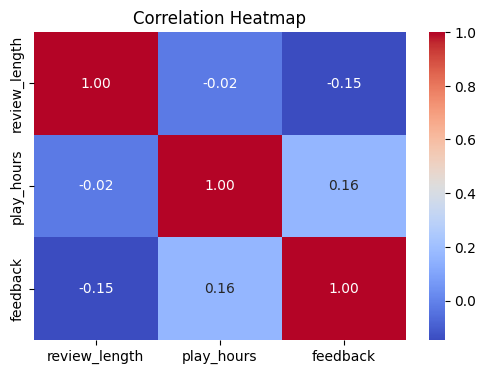

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = final_df[["review_length", "play_hours", "feedback"]]

corr_matrix = corr_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

 Key Insights-Correlation Matrix : 

 1. Playtime vs. Recommendation (0.16): Exhibits a slight positive correlation. As player engagement hours increase, the likelihood of a positive recommendation naturally trends upward.

 2. Review Length vs. Playtime (-0.02): Displays a completely flat statistical relationship. Total in-game hours do not dictate review length; short-term players are just as likely to write essays as hardcore completionists.

 3. Review Length vs. Recommendation (-0.15): Reveals a negative correlation. Longer text reviews are statistically driven by negative recommendations (feedback = 0).  

The Machine Learning Justification

Frustrated players are highly motivated to write long, exhaustive reviews, often detailing heavy technical grievances (such as PC port optimization bugs or performance frame drops) even after initially praising core elements like gameplay traversal or graphics. 

Because these lengthy negative reviews contain dense clusters of praise vocabulary alongside final dealbreakers, rule-based lexicon models like VADER fail to capture context perfectly, introducing noise. To overcome this, this project utilizes VADER Compound Scores and Review Length purely as engineered numerical features fed into advanced Machine Learning Classifiers—specifically comparing Logistic Regression, Random Forest, and XGBoost to accurately capture non-linear patterns and securely predict final player feedback

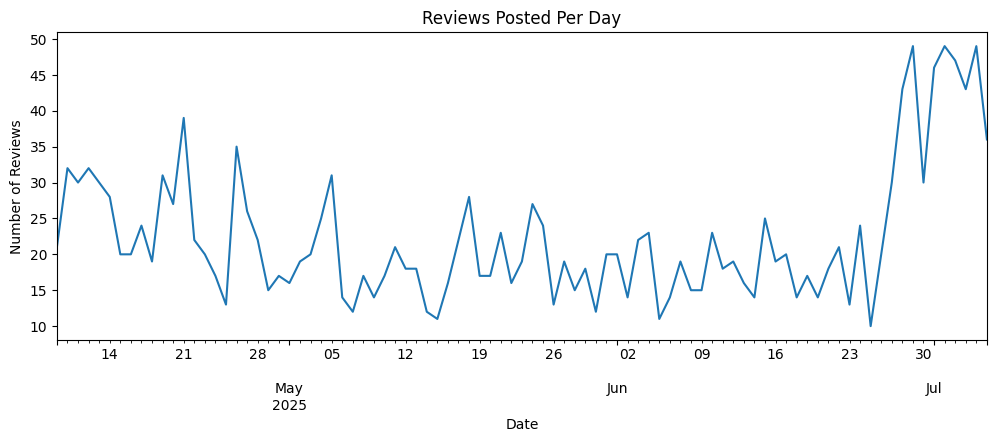

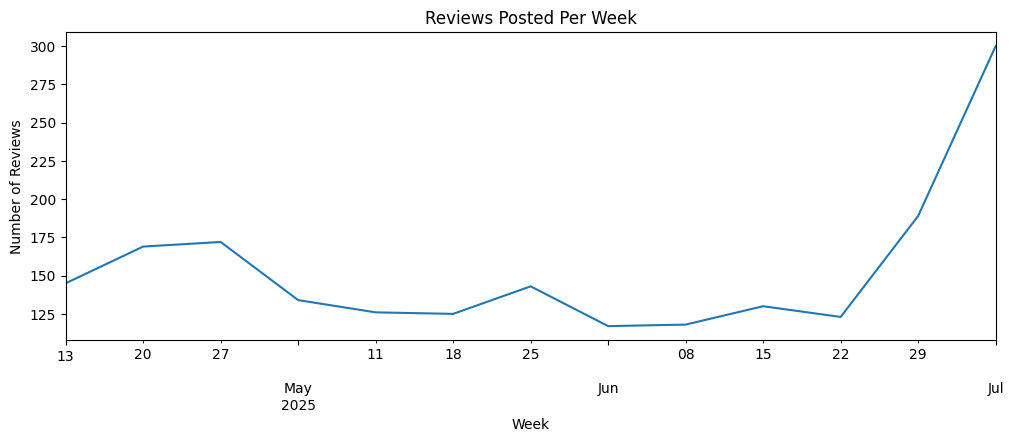

/var/folders/nz/59m3phqs5rg_30kcvrkxfsrw0000gn/T/ipykernel_34585/2887693243.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  reviews_per_month = final_df.groupby(pd.Grouper(key="date_posted", freq="M")).size()


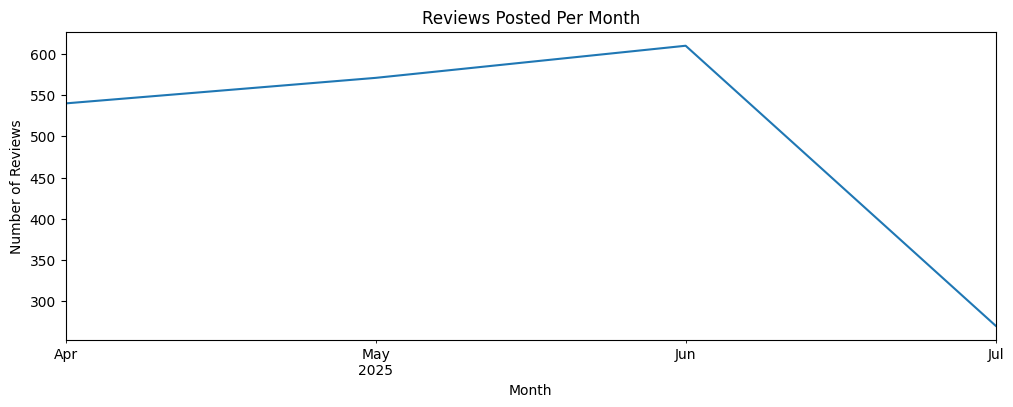

In [69]:
# Reviews per day
reviews_per_day = final_df.groupby("date_posted").size()
plt.figure(figsize=(12,4))
reviews_per_day.plot()
plt.title("Reviews Posted Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

# Reviews per week
reviews_per_week = final_df.groupby(pd.Grouper(key="date_posted", freq="W")).size()
plt.figure(figsize=(12,4))
reviews_per_week.plot()
plt.title("Reviews Posted Per Week")
plt.xlabel("Week")
plt.ylabel("Number of Reviews")
plt.show()

# Reviews per month
reviews_per_month = final_df.groupby(pd.Grouper(key="date_posted", freq="M")).size()
plt.figure(figsize=(12,4))
reviews_per_month.plot()
plt.title("Reviews Posted Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()



1. there are dips around the end of each week (weekends) and rises during weekdays. This might suggest that people are more likely to post reviews during their leisure time

2. Major spike in reviews in late june (could be due to game update ,sale event)

3. time-series analysis strongly suggests a significant event (most likely a major sale or content update) occurred around late June 2025,which might have led to increased review activity

May 2025: Appears to be a period where reviews were, on average, more detailed and perhaps from a more established player base (highest average review length, still high average play hours).

Late June/Early July 2025: A massive surge in the volume of reviews occurred. Crucially, during this same period, the average review length and average play hours of reviewers began to decline significantly.

This suggests that the surge in review volume was primarily driven by an influx of new players (likely due to a large sale event or promotion). These new players, having just started the game, naturally had lower play hours and tended to write shorter, initial reviews, thus lowering the overall monthly averages for both review length and play hours, even while the total count of reviews soared.

/var/folders/nz/59m3phqs5rg_30kcvrkxfsrw0000gn/T/ipykernel_34585/1270394081.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_review_length = final_df.groupby(pd.Grouper(key="date_posted", freq="M"))["review_length"].mean()


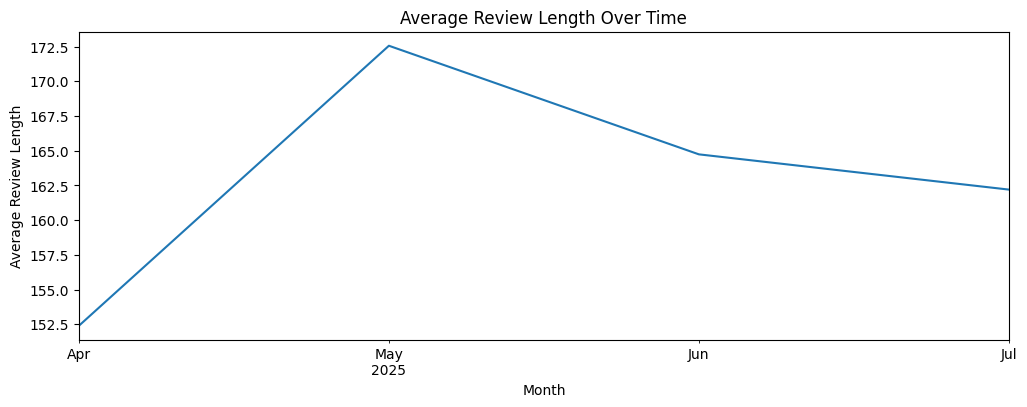

/var/folders/nz/59m3phqs5rg_30kcvrkxfsrw0000gn/T/ipykernel_34585/1270394081.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_play_hours = final_df.groupby(pd.Grouper(key="date_posted", freq="M"))["play_hours"].mean()


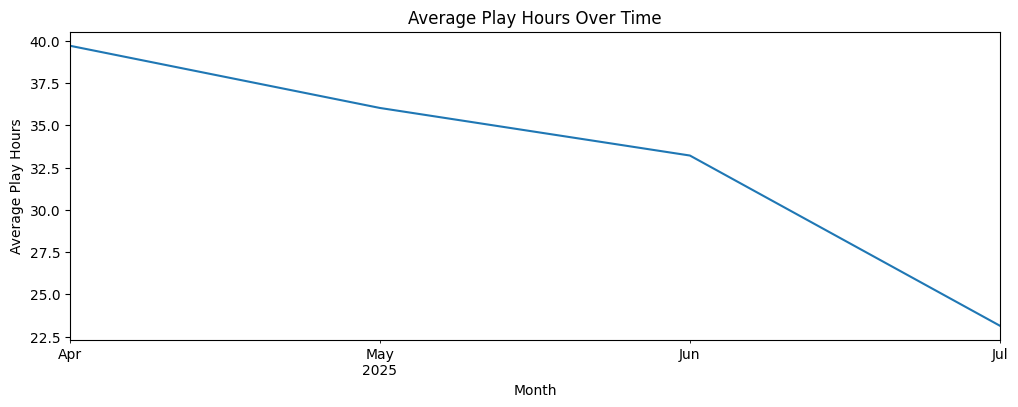

In [70]:
# Average review length over time (monthly)
monthly_review_length = final_df.groupby(pd.Grouper(key="date_posted", freq="M"))["review_length"].mean()
plt.figure(figsize=(12,4))
monthly_review_length.plot()
plt.title("Average Review Length Over Time")
plt.xlabel("Month")
plt.ylabel("Average Review Length")
plt.show()

# Average play hours over time (monthly)
monthly_play_hours = final_df.groupby(pd.Grouper(key="date_posted", freq="M"))["play_hours"].mean()
plt.figure(figsize=(12,4))
monthly_play_hours.plot()
plt.title("Average Play Hours Over Time")
plt.xlabel("Month")
plt.ylabel("Average Play Hours")
plt.show()

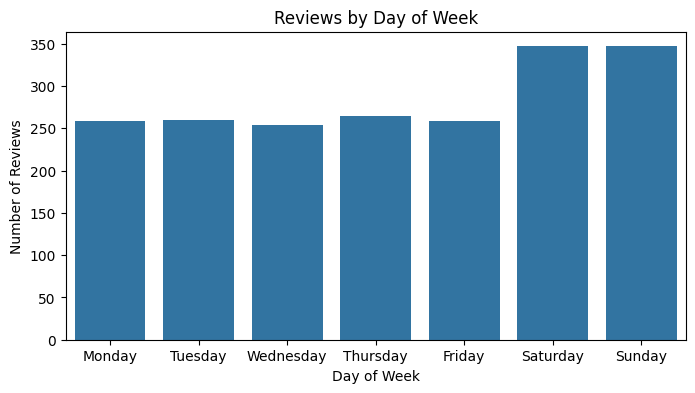

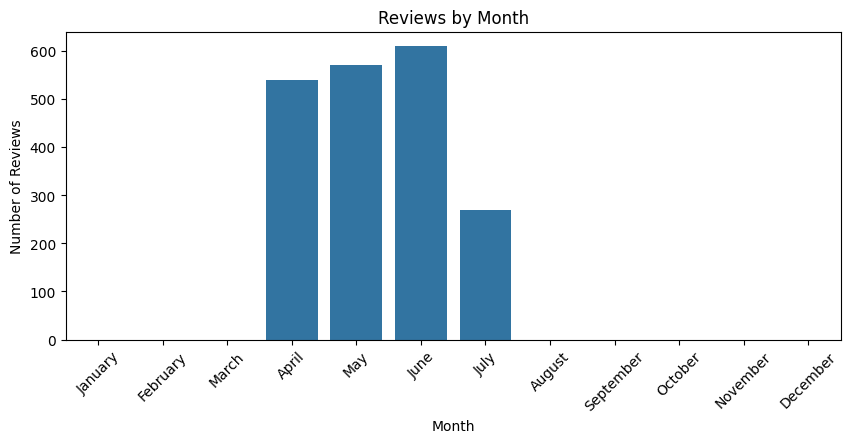

In [71]:
# Day of week pattern
final_df["day_of_week"] = final_df["date_posted"].dt.day_name()
plt.figure(figsize=(8,4))
sns.countplot(x="day_of_week", data=final_df, order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Reviews by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Reviews")
plt.show()

# Month pattern
final_df["month"] = final_df["date_posted"].dt.month_name()
plt.figure(figsize=(10,4))
sns.countplot(x="month", data=final_df, order=pd.date_range("2025-01-01", "2025-12-01", freq="MS").strftime("%B"))
plt.title("Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()


................

In [72]:

import nltk


nltk.data.path.append('/Users/mac/nltk_data')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for resource in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    try:
        nltk.data.find(f'corpora/{resource}' if resource != 'punkt' else f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource)

# Initialize NLTK tools
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor', 'never'}

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return "" # Handle nans

    # 1. Lowercasing
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove mentions and hashtags in reviews
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Remove punctuation and special characters
    # Keep only lowercase letters and spaces
    text = re.sub(r'[^a-z\s]', '', text) 

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenization
    tokens = word_tokenize(text)

    # 8. Remove Stop Words and Lemmatize
    # Ensure tokens are not empty before processing
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # 9. Join tokens back into a single string
    return " ".join(processed_tokens)

final_df["review_text"] = final_df['review_text'].astype(str)
final_df['processed_review_text'] = final_df["review_text"].apply(preprocess_text)



In [73]:
from nltk.sentiment import SentimentIntensityAnalyzer
try:
    if nltk.data.find('sentiment/vader_lexicon.zip'):
        print("vader_lexicon found")
    else:
        nltk.download("vader_lexicon")
except nltk.downloader.DownloadError:
    nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        # Handle empty or non-string inputs
        return {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}
    return analyzer.polarity_scores(text)["compound"]

# Apply the sentiment analysis
final_df['vader_sentiment_scores'] = final_df['processed_review_text'].apply(get_vader_sentiment)

final_df


vader_lexicon found


,review_text,review_length,feedback,play_hours,date_posted,day_of_week,month,processed_review_text,vader_sentiment_scores
0,10 out of 10 game but MJ is the main reason wh...,67,1,44.8,2025-07-06,Sunday,July,game mj main reason havent game year yet,0.0
1,best game ever,12,1,16.1,2025-07-06,Sunday,July,best game ever,0.6369
2,"this game is very good, is an anventure game i...",43,1,5.0,2025-07-06,Sunday,July,game good anventure game like,0.6597
3,not well optimized for now,22,0,2.5,2025-07-06,Sunday,July,not well optimized,-0.5096
4,cause,5,1,7.2,2025-07-06,Sunday,July,cause,0.0
...,...,...,...,...,...,...,...,...,...
1995,"The story in this game is disappointing, Krave...",847,0,27.7,2025-04-09,Wednesday,April,story game disappointing kraven absolutely was...,0.9424
1996,My favourite spider man game by far ^^\n\nI lo...,561,1,41.0,2025-04-09,Wednesday,April,favourite spider man game far love improvement...,0.9771
1997,good game. just wished it wasnt so heavy on th...,57,1,34.1,2025-04-09,Wednesday,April,good game wished wasnt heavy lgbtqwoke,0.4404
1998,Not as good as the first one but a great game ...,140,1,26.0,2025-04-09,Wednesday,April,not good first one great game great gameplay a...,0.8997


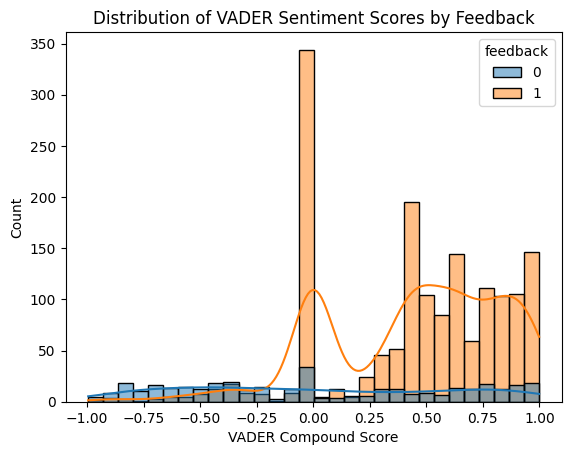

In [74]:
# Ensure vader_sentiment_scores is a float (compound score)
def extract_compound(val):
	if isinstance(val, dict):
		return val.get("compound", 0.0)
	try:
		return float(val)
	except Exception:
		return 0.0

final_df["vader_sentiment_scores"] = final_df["vader_sentiment_scores"].apply(extract_compound)

sns.histplot(data=final_df, x="vader_sentiment_scores", hue="feedback", bins=30, kde=True)
plt.title("Distribution of VADER Sentiment Scores by Feedback")
plt.xlabel("VADER Compound Score")
plt.ylabel("Count")
plt.show()

In [75]:
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

recommended_reviews_df = final_df[final_df['feedback'] == 1]
total_recommended_reviews = recommended_reviews_df.shape[0]

print(f"Total number of 'Positive Reviews': {total_recommended_reviews}")


if total_recommended_reviews == 0:
    print("No 'Recommended' reviews found to analyze sentiment breakdown.")
else:

    # Positive VADER sentiment
    count_recommended_positive_vader = recommended_reviews_df[
        recommended_reviews_df['vader_sentiment_scores'] >= VADER_POSITIVE_THRESHOLD
    ].shape[0]

    # Neutral VADER sentiment
    count_recommended_neutral_vader = recommended_reviews_df[
        (recommended_reviews_df['vader_sentiment_scores'] > VADER_NEGATIVE_THRESHOLD) &
        (recommended_reviews_df['vader_sentiment_scores'] < VADER_POSITIVE_THRESHOLD)
    ].shape[0]

    # Negative VADER sentiment
    count_recommended_negative_vader = recommended_reviews_df[
        recommended_reviews_df['vader_sentiment_scores'] <= VADER_NEGATIVE_THRESHOLD
    ].shape[0]

    # Calculate percentages
    percentage_recommended_positive_vader = (count_recommended_positive_vader / total_recommended_reviews) * 100
    percentage_recommended_neutral_vader = (count_recommended_neutral_vader / total_recommended_reviews) * 100
    percentage_recommended_negative_vader = (count_recommended_negative_vader / total_recommended_reviews) * 100

    print(f"\nPercentage of 'Recommended' reviews that VADER classified as 'Positive': {percentage_recommended_positive_vader:.2f}%")
    print(f"Percentage of 'Recommended' reviews that VADER classified as 'Neutral': {percentage_recommended_neutral_vader:.2f}%")
    print(f"Percentage of 'Recommended' reviews that VADER classified as 'Negative': {percentage_recommended_negative_vader:.2f}%")


Total number of 'Positive Reviews': 1627

Percentage of 'Recommended' reviews that VADER classified as 'Positive': 73.26%
Percentage of 'Recommended' reviews that VADER classified as 'Neutral': 21.27%
Percentage of 'Recommended' reviews that VADER classified as 'Negative': 5.47%


In [76]:
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05


negative_reviews_df = final_df[final_df['feedback'] == 0]
total_negative_reviews = negative_reviews_df.shape[0]

print(f"Total number of 'Negative Reviews': {total_negative_reviews}")

if total_negative_reviews == 0:
    print("No 'Negative Reviews' found to analyze sentiment breakdown.")
else:

    # Positive VADER sentiment
    count_negative_positive_vader = negative_reviews_df[
        negative_reviews_df['vader_sentiment_scores'] >= VADER_POSITIVE_THRESHOLD
    ].shape[0]

    # Neutral VADER sentiment
    count_negative_neutral_vader = negative_reviews_df[
        (negative_reviews_df['vader_sentiment_scores'] > VADER_NEGATIVE_THRESHOLD) &
        (negative_reviews_df['vader_sentiment_scores'] < VADER_POSITIVE_THRESHOLD)
    ].shape[0]

    # Negative VADER sentiment
    count_negative_negative_vader = negative_reviews_df[
        negative_reviews_df['vader_sentiment_scores'] <= VADER_NEGATIVE_THRESHOLD
    ].shape[0]

    # Calculate percentages
    percentage_negative_positive_vader = (count_negative_positive_vader / total_negative_reviews) * 100
    percentage_negative_neutral_vader = (count_negative_neutral_vader / total_negative_reviews) * 100
    percentage_negative_negative_vader = (count_negative_negative_vader / total_negative_reviews) * 100

    print(f"\nPercentage of 'Negative Reviews' that VADER classified as 'Positive': {percentage_negative_positive_vader:.2f}%")
    print(f"Percentage of 'Negative Reviews' that VADER classified as 'Neutral': {percentage_negative_neutral_vader:.2f}%")
    print(f"Percentage of 'Negative Reviews' that VADER classified as 'Negative': {percentage_negative_negative_vader:.2f}%")


Total number of 'Negative Reviews': 364

Percentage of 'Negative Reviews' that VADER classified as 'Positive': 42.31%
Percentage of 'Negative Reviews' that VADER classified as 'Neutral': 9.07%
Percentage of 'Negative Reviews' that VADER classified as 'Negative': 48.63%


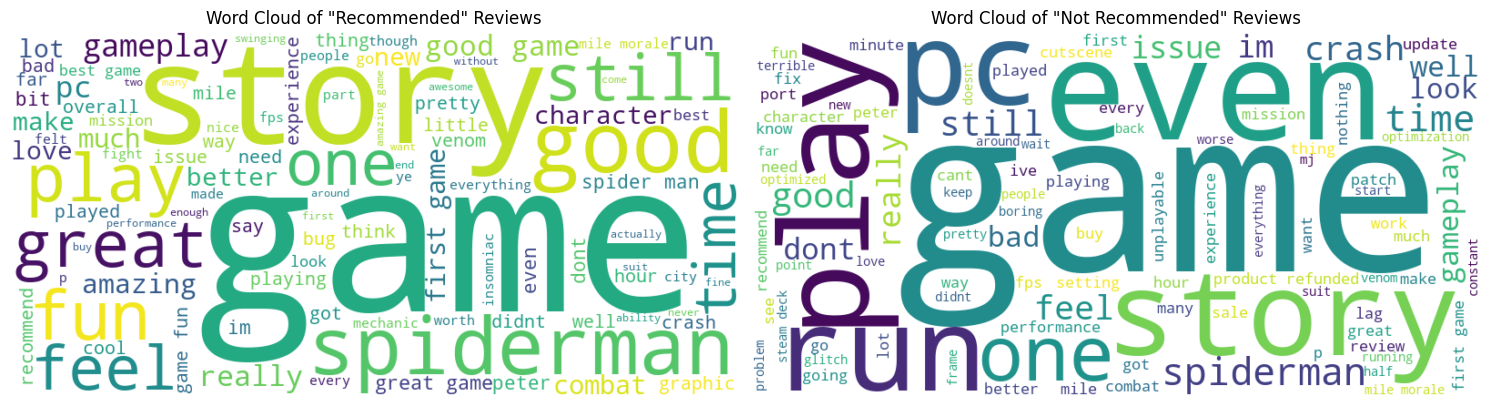

Word Clouds generated for Recommended and Not Recommended reviews.


In [77]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate reviews by feedback type
recommended_reviews = ' '.join(final_df[final_df['feedback'] == 1]['processed_review_text'])
not_recommended_reviews = ' '.join(final_df[final_df['feedback'] == 0]['processed_review_text'])

# Generate Word Cloud for Recommended Reviews
wordcloud_rec = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    contour_width=3,
    contour_color='green' # Positive color
).generate(recommended_reviews)

# Generate Word Cloud for Not Recommended Reviews
wordcloud_not_rec = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    contour_width=3,
    contour_color='red' # Negative color
).generate(not_recommended_reviews)

# Plotting both
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1) 
plt.imshow(wordcloud_rec, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of "Recommended" Reviews')

plt.subplot(1, 2, 2) 
plt.imshow(wordcloud_not_rec, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of "Not Recommended" Reviews')

plt.tight_layout()
plt.show()

print("Word Clouds generated for Recommended and Not Recommended reviews.")

1. Recommended : largest words here are "game", "story", "good", "play", "feel", and "great". Players highly appreciate the storyline

2. Not Recommended : "glitch", "performance", "issue", "optimization", and "frame". Players do not recommend the game primarily due to technical problems

In [78]:
final_df.to_csv("../Final_Reviews.csv",index = False)